# EDA — organic_ratio cleaned target table

Загружает `data/train/targets_train_clean.parquet` и смотрит:
1. shape, dtypes, NaN map
2. распределение target (`organic_share`)
3. распределение `total_installs` (масса когорт)
4. target по платформам и топ-странам
5. корреляции с target (топ-20)
6. multicollinearity (corr matrix топ-фичей)

Запускать из корня проекта (`cd organic_ratio && jupyter lab`).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root(start: Path, max_depth_down: int = 4) -> Path:
    """Search upward, then downward from `start` for src/organic_ratio."""
    # 1) walk up
    for p in [start, *start.parents]:
        if (p / "src" / "organic_ratio").is_dir():
            return p

    # 2) walk down, breadth-limited
    queue = [(start, 0)]
    seen = set()
    while queue:
        cur, depth = queue.pop(0)
        if cur in seen or depth > max_depth_down:
            continue
        seen.add(cur)
        if (cur / "src" / "organic_ratio").is_dir():
            return cur
        try:
            for child in cur.iterdir():
                if child.is_dir() and not child.name.startswith("."):
                    queue.append((child, depth + 1))
        except PermissionError:
            continue

    # 3) explicit override via env var
    env_root = os.environ.get("ORGANIC_RATIO_ROOT")
    if env_root and (Path(env_root) / "src" / "organic_ratio").is_dir():
        return Path(env_root)

    raise RuntimeError(
        f"organic_ratio src not found near {start}. "
        f"Set ORGANIC_RATIO_ROOT env var to the project directory."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

os.chdir(PROJECT_ROOT)
print("project root:", PROJECT_ROOT)
print("cwd:", Path.cwd())

from organic_ratio.utils.config import load_config

sns.set_context("notebook")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)

project root: /home/jovyan/KEDRO/organic_ratio
cwd: /home/jovyan/KEDRO/organic_ratio


In [2]:
cfg = load_config()
out_cfg = cfg.datasets.targets

train_path = Path(out_cfg.train_dir) / out_cfg.train_clean_filename
test_path = Path(out_cfg.test_dir) / out_cfg.test_clean_filename

train = pl.read_parquet(train_path).to_pandas()
test = pl.read_parquet(test_path).to_pandas()

print(f"train: {train.shape}")
print(f"test:  {test.shape}")
train.head()

train: (14869, 111)
test:  (2069, 111)


,platform,country_code,install_date,total_installs,organic_installs,organic_share,cohort_size,n_calendar_days,ads_0,ads_1,ads_2,ads_3,ads_4,ads_5,ads_6,ads_7,ads_count_0,ads_count_1,ads_count_2,ads_count_3,ads_count_4,ads_count_5,ads_count_6,ads_count_7,ads_cum_learn,log1p_ads_cum_learn,ads_days_with_purchase_learn,ads_purchase_count_learn,ads_avg_check_learn,ads_rev_d1,ads_rev_d3,iap_0,iap_1,iap_2,iap_3,iap_4,iap_5,iap_6,iap_7,iap_count_0,iap_count_1,iap_count_2,iap_count_3,iap_count_4,iap_count_5,iap_count_6,iap_count_7,iap_check_size_0,iap_check_size_1,iap_check_size_2,iap_check_size_3,iap_check_size_4,iap_check_size_5,iap_check_size_6,iap_check_size_7,time_to_first_iap_minutes,time_first_and_second_iap_minutes,iap_cum_learn,log1p_iap_cum_learn,iap_days_with_purchase_learn,iap_purchase_count_learn,iap_avg_check_learn,rev_d1_iap,rev_d3_iap,d1_share_iap,avg_check_d1_3_iap,avg_check_d4_7_iap,acceleration_iap,has_second_iap,time_between_iap_2_3,n_sessions_total,active_days_7d,weekend_sessions,sessions_0,sessions_1,sessions_2,sessions_3,sessions_4,sessions_5,sessions_6,sessions_7,ret_0,ret_1,ret_2,ret_3,ret_4,ret_5,ret_6,ret_7,density_1d,density_3d,density_7d,weekend_ratio,lag_first_session,lag_last_session,session_span_days,avg_gap_day7,med_gap_day7,max_gap_day7,sessions_d1,session_velocity_slope,last_active_day,zero_session_days,spend,installs_spend,impressions,clicks,cpi,ctr,cvr,cpm
0,android,tr,2024-12-17,435,79,0.181609,435,1,28.718893,15.840169,8.619275,5.896420,4.020531,3.889452,5.785157,4.198074,137.0,72.0,56.0,48.0,43.0,38.0,33.0,33.0,76.967971,40.244295,2.555556,460,0.136521,44.559062,59.074757,14.676003,34.859145,1.917207,14.211149,11.951394,14.026149,15.185486,64.670042,6.0,16.0,1.0,5.0,4.0,3.0,3.0,7.0,12.995579,16.015749,1.917207,7.567005,5.975697,9.767344,15.185486,22.494083,19919.718627,450.886275,171.496574,24.258097,1.529412,45,1.891482,49.535149,65.663504,0.436950,1.489311,1.434329,9.282996e+06,0.588235,493.100000,12.540230,2.473563,2.170115,1579.0,824.0,670.0,579.0,493.0,451.0,475.0,384,1.0,0.326437,0.239080,0.225287,0.188506,0.183908,0.170115,0.140230,0.088660,0.037315,0.019228,0.055789,0.0,1.908046,1.908046,962.048569,684.178161,2360.887356,5.524138,-0.297017,2.908046,1.696252e+18,4850.264265,5262.0,1707442.0,239667.0,1.008269,0.290912,0.158375,5.003140
1,android,at,2025-01-06,61,22,0.360656,61,1,14.424599,3.352660,0.152899,0.063813,0.103566,0.089029,0.467362,0.033264,9.0,7.0,2.0,1.0,1.0,2.0,2.0,1.0,18.687192,7.276803,2.083333,25,0.816564,17.777259,17.993971,1.972251,9.919720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.972251,9.919720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1350.250000,831.133333,11.891971,2.556605,2.000000,2,5.945985,11.891971,11.891971,0.495783,5.945985,0.000000,0.000000e+00,1.000000,0.000000,5.636364,1.800000,0.454545,146.0,58.0,36.0,17.0,15.0,17.0,8.0,13,1.0,0.272727,0.163636,0.072727,0.090909,0.090909,0.054545,0.054545,0.081473,0.011836,0.008127,0.022745,0.0,1.163636,1.163636,118.075000,75.272727,326.127273,3.709091,-0.268398,2.163636,5.200000e+00,310.033571,129.0,38648.0,3890.0,2.543977,0.733228,0.146627,252.100400
2,android,it,2024-12-20,209,26,0.124402,209,1,9.767292,2.997966,2.025310,1.648205,2.248322,1.058501,1.317291,0.296134,50.0,26.0,21.0,19.0,18.0,14.0,14.0,9.0,21.359021,14.070215,2.590909,171,0.148215,12.765258,16.438773,3.113967,0.000000,1.920676,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.113967,0.000000,1.920676,0.000000,0.000000,0.000000,0.000000,0.000000,83824.888889,0.000000,5.034643,2.486203,0.666667,2,1.678214,3.113967,5.034643,0.435865,1.678214,0.000000,0.000000e+00,0.000000,0.000000,9.466346,2.158654,2.442308,599.0,261.0,247.0,206.0,226.0,161.0,161.0,108,1.0,0.240385,0.192308,0.173077,0.168269,0.139423,0.125000,0.120192,0.058034,0.031769,0.012168,0.095019,0.0,1.538462,1.538462,1220.429106,1052.086538,1985.158654,4.134615,-0.238954,2.538462,1.418980e+18,5395.860291,3107.0,3339

## 1. Schema + NaN map

In [3]:
n = len(train)
info = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "n_unique": train.nunique(),
    "n_null": train.isna().sum(),
    "pct_null": (train.isna().sum() / n * 100).round(2),
})
info.sort_values("pct_null", ascending=False).head(40)

,dtype,n_unique,n_null,pct_null
time_to_first_iap_minutes,float64,10648,4212,28.33
time_first_and_second_iap_minutes,float64,7295,4212,28.33
time_between_iap_2_3,float64,6025,4212,28.33
has_second_iap,float64,494,4212,28.33
acceleration_iap,float64,6209,4212,28.33
avg_check_d4_7_iap,float64,6185,4212,28.33
avg_check_d1_3_iap,float64,9171,4212,28.33
d1_share_iap,float64,1134,4212,28.33
iap_avg_check_learn,float64,9544,4212,28.33
iap_days_with_purchase_learn,float64,733,4212,28.33


## 2. Distribution of `organic_share`

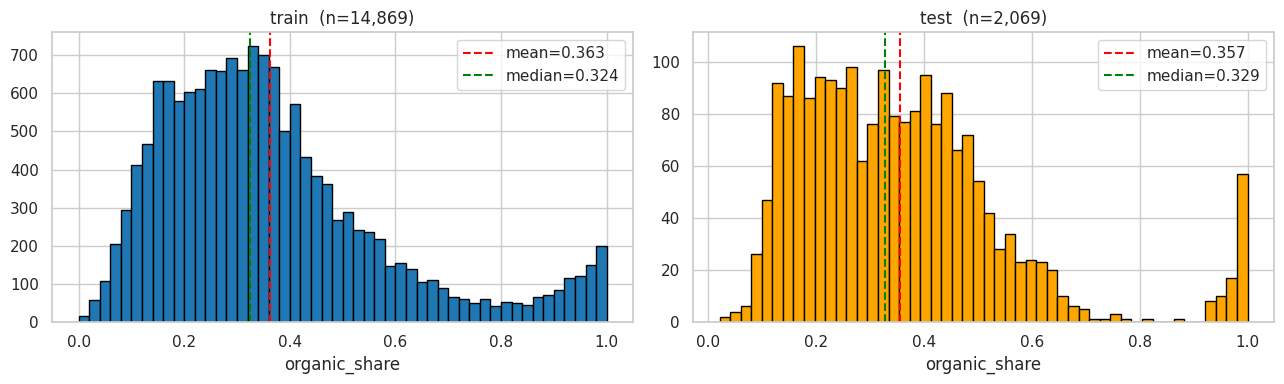

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train["organic_share"], bins=50, edgecolor="black")
axes[0].set_title(f"train  (n={len(train):,})")
axes[0].set_xlabel("organic_share")
axes[0].axvline(train["organic_share"].mean(), color="r", ls="--", label=f"mean={train['organic_share'].mean():.3f}")
axes[0].axvline(train["organic_share"].median(), color="g", ls="--", label=f"median={train['organic_share'].median():.3f}")
axes[0].legend()

axes[1].hist(test["organic_share"], bins=50, edgecolor="black", color="orange")
axes[1].set_title(f"test  (n={len(test):,})")
axes[1].set_xlabel("organic_share")
axes[1].axvline(test["organic_share"].mean(), color="r", ls="--", label=f"mean={test['organic_share'].mean():.3f}")
axes[1].axvline(test["organic_share"].median(), color="g", ls="--", label=f"median={test['organic_share'].median():.3f}")
axes[1].legend()

plt.tight_layout()
plt.show()

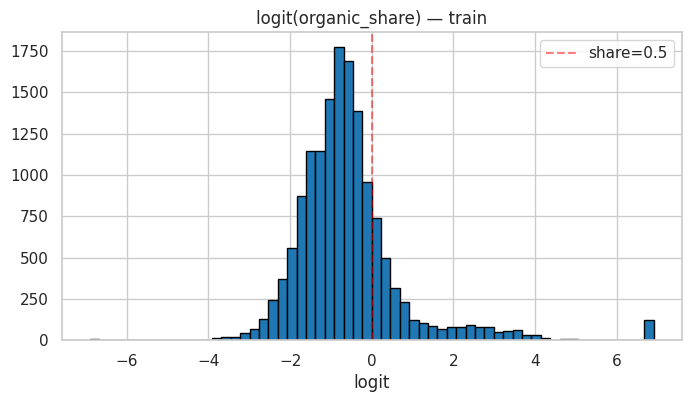

In [5]:
# logit(y) — если хвосты у 0/1 тонкие, логит ляжет нормально и можно делать линейный регрессор
eps = 1e-3
y_clip = train["organic_share"].clip(eps, 1 - eps)
logit_y = np.log(y_clip / (1 - y_clip))

plt.figure(figsize=(8, 4))
plt.hist(logit_y, bins=60, edgecolor="black")
plt.title("logit(organic_share) — train")
plt.xlabel("logit")
plt.axvline(0, color="r", ls="--", alpha=0.5, label="share=0.5")
plt.legend()
plt.show()

## 3. `total_installs` — масса когорт

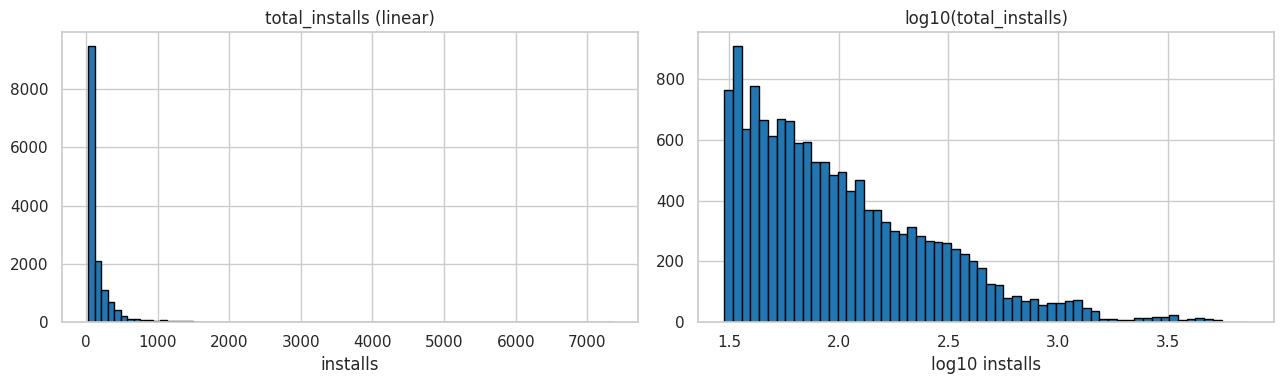

count    14869.000000
mean       199.672204
std        416.328668
min         30.000000
10%         36.000000
25%         47.000000
50%         83.000000
75%        186.000000
90%        401.000000
95%        676.600000
99%       2158.400000
max       7337.000000
Name: total_installs, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train["total_installs"], bins=80, edgecolor="black")
axes[0].set_title("total_installs (linear)")
axes[0].set_xlabel("installs")

axes[1].hist(np.log10(train["total_installs"]), bins=60, edgecolor="black")
axes[1].set_title("log10(total_installs)")
axes[1].set_xlabel("log10 installs")

plt.tight_layout()
plt.show()

print(train["total_installs"].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

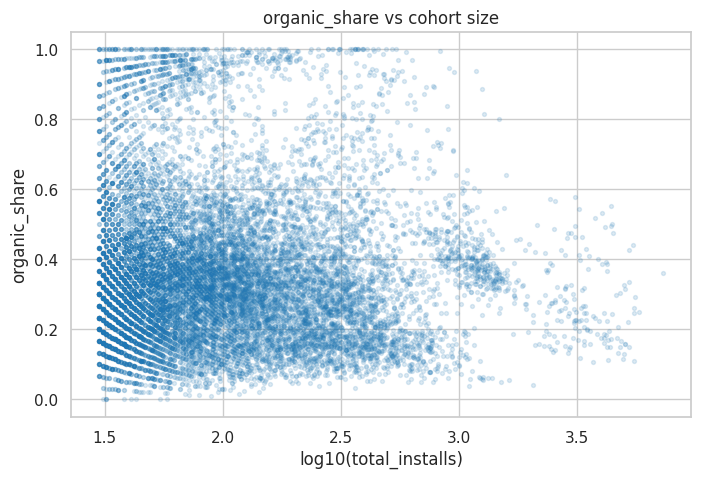

In [7]:
# проверка: маленькие когорты должны давать более «шумный» (расплывчатый) target
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(np.log10(train["total_installs"]), train["organic_share"], alpha=0.15, s=8)
ax.set_xlabel("log10(total_installs)")
ax.set_ylabel("organic_share")
ax.set_title("organic_share vs cohort size")
plt.show()

## 4. organic_share по платформам и топ-странам

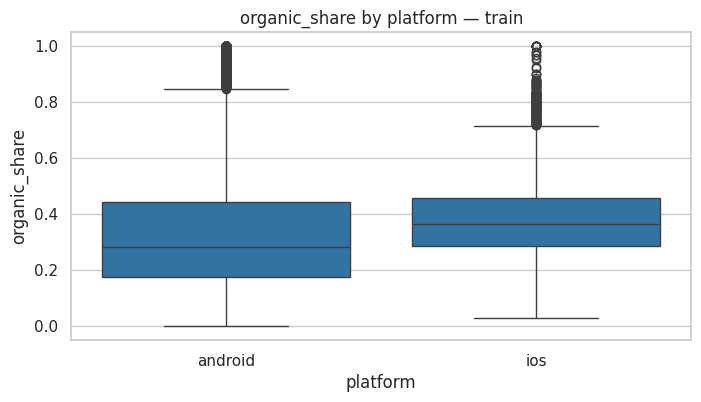

          count      mean       std    median
platform                                     
android    9664  0.351098  0.240629  0.283019
ios        5205  0.384499  0.146234  0.363636


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=train, x="platform", y="organic_share", ax=ax)
ax.set_title("organic_share by platform — train")
plt.show()

print(train.groupby("platform")["organic_share"].agg(["count", "mean", "std", "median"]))

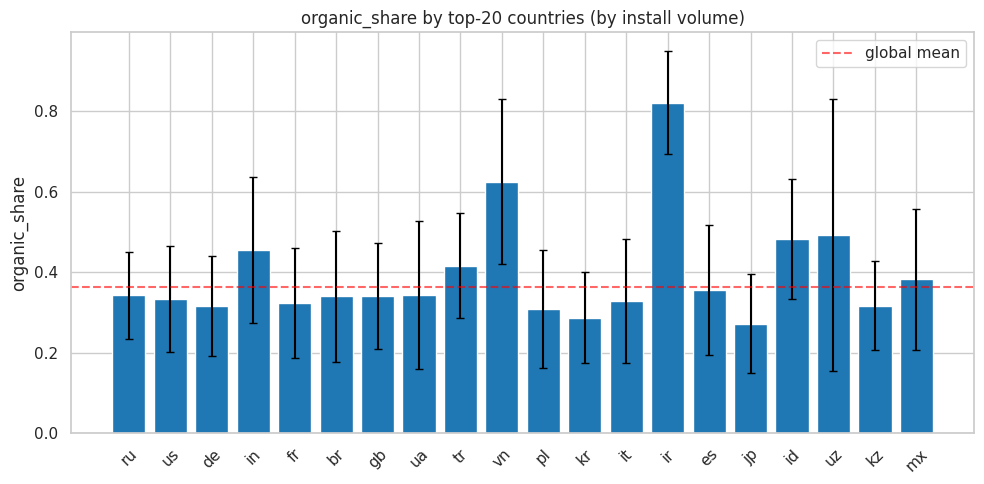

,country_code,n_cohorts,total_installs,share_mean,share_std
0,ru,362,789317,0.343060,0.108253
1,us,362,308059,0.334319,0.132397
2,de,362,127569,0.316906,0.124296
3,in,263,104387,0.456528,0.181550
4,fr,362,100865,0.324042,0.136072
5,br,351,98740,0.340403,0.161971
6,gb,362,88083,0.341335,0.132411
7,ua,356,81094,0.343380,0.184313
8,tr,362,80092,0.416889,0.130006
9,vn,359,75499,0.625039,0.204986


In [9]:
country_stats = (
    train.groupby("country_code")
    .agg(n_cohorts=("organic_share", "size"),
         total_installs=("total_installs", "sum"),
         share_mean=("organic_share", "mean"),
         share_std=("organic_share", "std"))
    .sort_values("total_installs", ascending=False)
)
top20 = country_stats.head(20).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top20["country_code"], top20["share_mean"], yerr=top20["share_std"], capsize=3)
ax.set_title("organic_share by top-20 countries (by install volume)")
ax.set_ylabel("organic_share")
ax.axhline(train["organic_share"].mean(), color="r", ls="--", alpha=0.6, label="global mean")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

top20

## 5. Корреляция фичей с target

In [10]:
TARGET = "organic_share"
DROP = {"organic_share", "organic_installs", "total_installs",
        "country_code", "platform", "install_date"}

num_cols = [c for c in train.select_dtypes(include=[np.number]).columns if c not in DROP]
print(f"numeric features for correlation: {len(num_cols)}")

# Pearson + Spearman (Spearman устойчив к выбросам и нелинейностям)
pearson = train[num_cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
spearman = train[num_cols + [TARGET]].corr(method="spearman", numeric_only=True)[TARGET].drop(TARGET)

corr_df = pd.DataFrame({
    "pearson": pearson,
    "spearman": spearman,
    "abs_spearman": spearman.abs(),
}).sort_values("abs_spearman", ascending=False)

corr_df.head(25)

numeric features for correlation: 105


,pearson,spearman,abs_spearman
installs_spend,-0.065198,-0.409588,0.409588
spend,-0.051776,-0.371504,0.371504
impressions,-0.053921,-0.368821,0.368821
clicks,-0.052779,-0.349405,0.349405
ads_0,-0.098277,-0.236487,0.236487
ads_cum_learn,-0.090991,-0.232537,0.232537
log1p_ads_cum_learn,-0.092637,-0.230751,0.230751
ads_rev_d1,-0.092411,-0.228878,0.228878
ads_7,-0.086172,-0.228760,0.228760
ads_rev_d3,-0.090997,-0.227788,0.227788


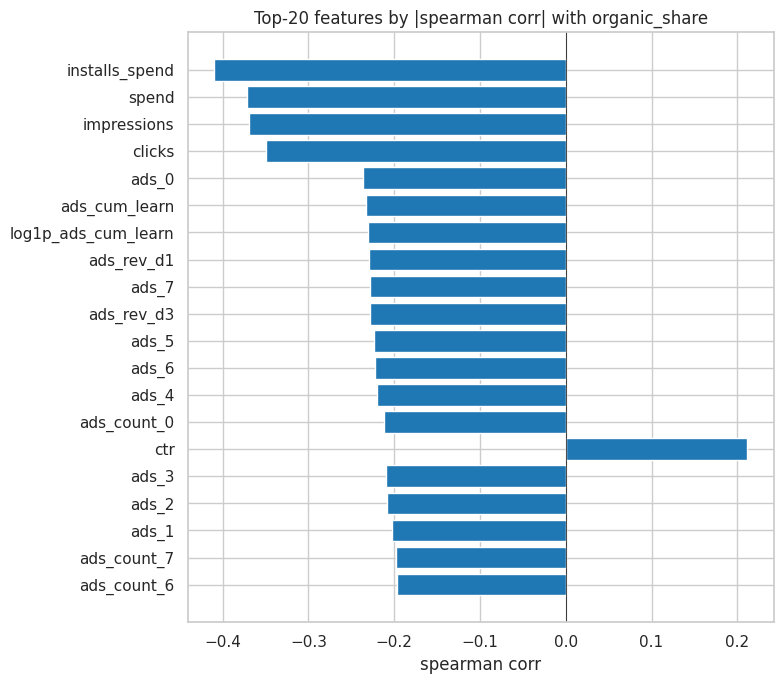

In [11]:
top = corr_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top["spearman"])
ax.axvline(0, color="k", lw=0.5)
ax.set_title("Top-20 features by |spearman corr| with organic_share")
ax.set_xlabel("spearman corr")
plt.tight_layout()
plt.show()

## 6. Multicollinearity (топ-фичи между собой)

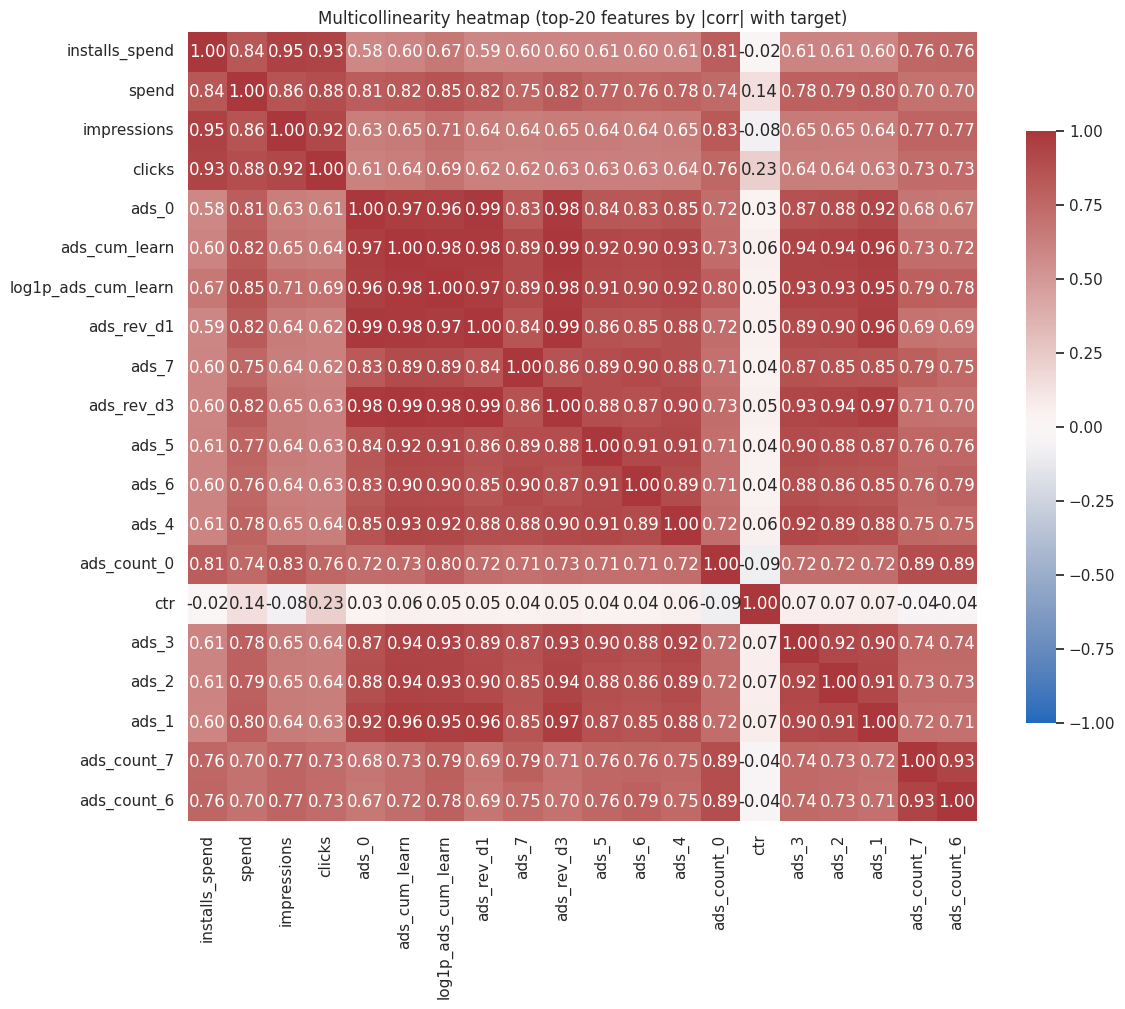

In [12]:
TOP_N = 20
top_features = corr_df.head(TOP_N).index.tolist()

mc = train[top_features].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(mc, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title(f"Multicollinearity heatmap (top-{TOP_N} features by |corr| with target)")
plt.tight_layout()
plt.show()

In [13]:
# топ-30 пар фичей с самой сильной корреляцией между собой (≥ 0.8 — кандидаты на дроп)
abs_mc = mc.abs()
tri = abs_mc.where(np.triu(np.ones(abs_mc.shape), k=1).astype(bool))
pairs = (
    tri.stack()
    .sort_values(ascending=False)
    .head(30)
    .reset_index()
    .rename(columns={"level_0": "feat_a", "level_1": "feat_b", 0: "abs_spearman"})
)
pairs

,feat_a,feat_b,abs_spearman
0,ads_cum_learn,ads_rev_d3,0.994510
1,ads_rev_d1,ads_rev_d3,0.993563
2,ads_0,ads_rev_d1,0.988759
3,ads_cum_learn,ads_rev_d1,0.983996
4,ads_cum_learn,log1p_ads_cum_learn,0.982846
5,log1p_ads_cum_learn,ads_rev_d3,0.979696
6,ads_0,ads_rev_d3,0.977934
7,log1p_ads_cum_learn,ads_rev_d1,0.972401
8,ads_0,ads_cum_learn,0.966679
9,ads_rev_d3,ads_1,0.965808


## 7. Динамика во времени

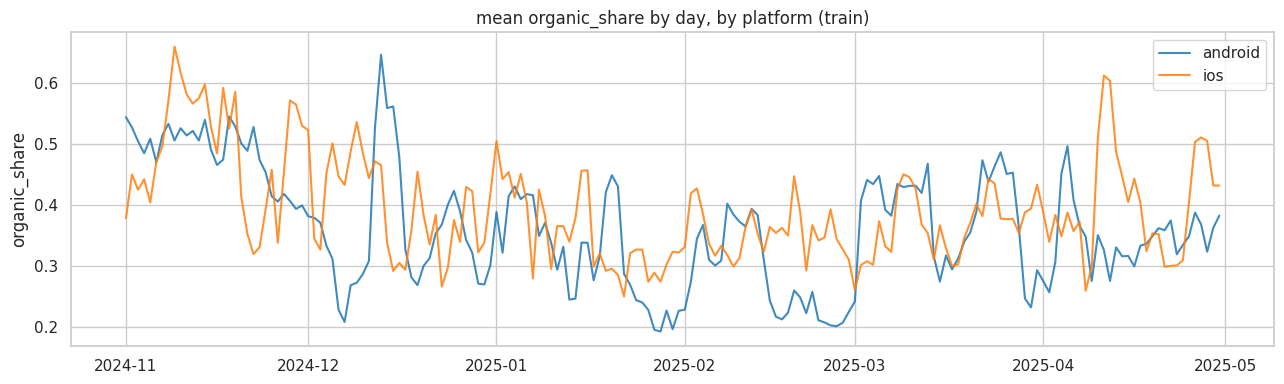

In [14]:
daily = (
    train.assign(install_date=pd.to_datetime(train["install_date"]))
    .groupby(["install_date", "platform"])
    .agg(share=("organic_share", "mean"),
         n=("organic_share", "size"),
         installs=("total_installs", "sum"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 4))
for p, sub in daily.groupby("platform"):
    ax.plot(sub["install_date"], sub["share"], label=p, alpha=0.85)
ax.set_title("mean organic_share by day, by platform (train)")
ax.set_ylabel("organic_share")
ax.legend()
plt.tight_layout()
plt.show()

## Что искать в выводе

- **Schema/NaN**: сколько пропусков в `cpi/ctr/cvr/cpm` (когорты без paid spend). Это сигнал, не шум — в модели можно или заполнять 0, или явно кодировать `has_paid_spend` бинарным флагом.
- **organic_share hist**: должен быть унимодальный или умеренно-скошенный, без пиков на 0/1.
- **logit(y)**: если близко к нормальному → линейная регрессия в logit-пространстве будет работать; если хвосты тяжёлые → нужно Beta-likelihood (PyMC).
- **scatter share vs size**: разброс должен сужаться с ростом cohort_size (так и должно быть — большая когорта = устойчивая оценка).
- **by-platform / by-country**: видим ли структурные различия — это аргумент за иерархическую модель с partial pooling.
- **Top-corr features**: интуитивные ли это предикторы? UA-метрики (`spend`, `clicks`, `cpi`) должны коррелировать отрицательно с organic_share, retention-метрики — менее очевидно.
- **Multicollinearity**: `spend ↔ impressions ↔ clicks ↔ installs_spend` будут на 0.9+ — для линейных моделей нужно выбрать одну из них либо PCA / VIF.
- **Time series**: должны быть видны спады/всплески в дни компанийных событий (релизы, акции).